[0. 1.]
(256, 256, 3)


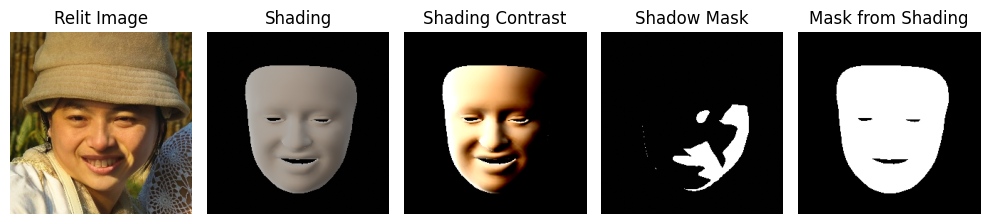

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

fi = 57
path = "/data/mint/sampling/TPAMI_MajorRevision/FixPlastic/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_SD256_rot2_1.0C/ema_300000/valid/render_face/reverse_sampling/src=66943.jpg/dst=68146.jpg/Lerp_1000/n_frames=60/"

shadow = f'{path}/dst_shadm_shad_frame{fi}.png'
img = f'{path}/res_frame{fi}.png'
shading = f'{path}/dst_ren_frame{fi}.png'

im_shadow = np.array(Image.open(shadow)) / 255.
im_img = np.array(Image.open(img)) / 255.
im_shading = np.array(Image.open(shading)) / 255.
# mask_from_shading = (im_shading.mean(axis=-1, keepdims=True) < 0.1).astype(np.float32)
mask_from_shading = (im_shading > 0.1).astype(np.float32)
print(np.unique(mask_from_shading))

# adjust contrast on shading with median with mask from shading
median = np.median(im_shading[mask_from_shading==1], axis=0, keepdims=True)
# Push below median to smaller values, above median to larger values
im_shading_contrast = (im_shading - median) * 5 + median
im_shading_contrast = np.clip(im_shading_contrast, 0, 1)

# adjust contrast on shading with median with mask from shadow
median = np.median(im_shading[shadow==1.0], axis=0, keepdims=True)
# Push below median to smaller values, above median to larger values
im_shadow_contrast = (im_shading - median) * 5 + median
im_shadow_contrast = np.clip(im_shadow_contrast, 0, 1)

img = [im_img, im_shading, im_shading_contrast, im_shadow_contrast, im_shadow, mask_from_shading]
name = ['Relit Image', 'Shading', 'Shading Contrast', 'Shadow Contrast', 'Mask from Shading']
n = len(img)
fig, axs = plt.subplots(1, n, figsize=(10, 4))
for i in range(n):
    axs[i].imshow(img[i])
    axs[i].set_title(name[i])
    axs[i].axis('off')
plt.tight_layout()
plt.show()